Loading data and engineering features...
Training models on sentiment to predict daily changes...

--- RESULTS ---
Baseline MAE to beat: $45.89
Advanced Emotion AI MAE: $20.09


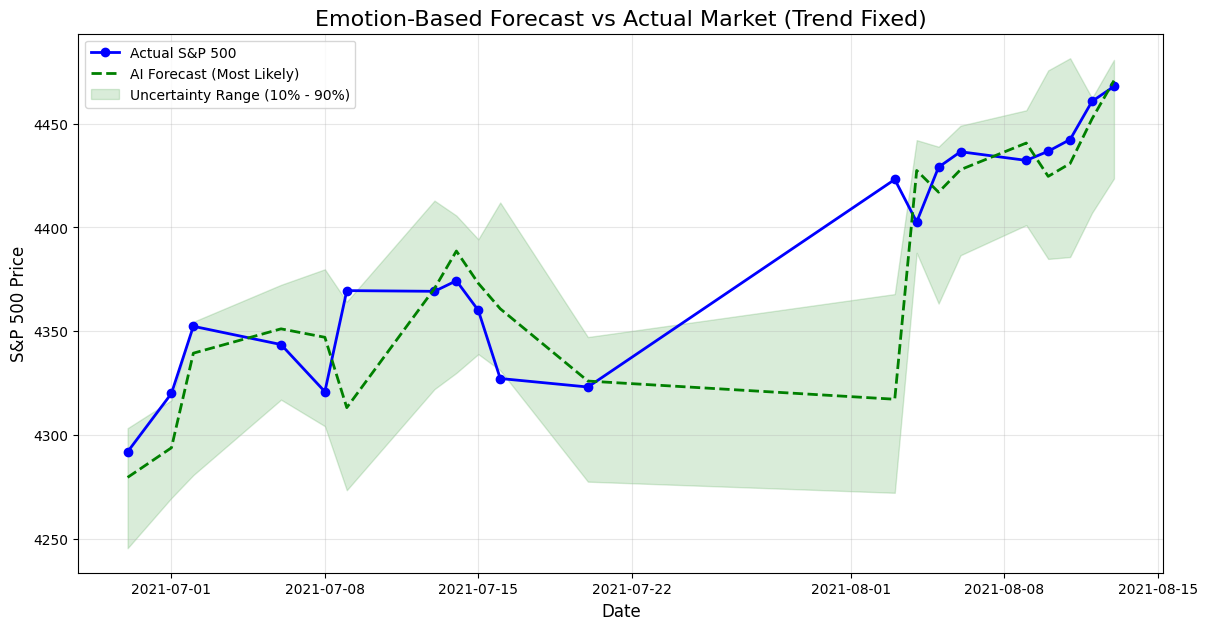

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

print("Loading data and engineering features...")
df = pd.read_csv('../assets/final_training_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Post_Count'] > 50].reset_index(drop=True)

# 1. Feature Engineering
df['Prev_Close'] = df['SP500_Close'].shift(1)
df['Prev_Sentiment'] = df['Daily_Emotion_Score'].shift(1)
df['Prev_Hype'] = df['Total_Hype_Volume'].shift(1)

# THE FIX: Calculate the daily price change to predict
df['Price_Change'] = df['SP500_Close'] - df['Prev_Close']

df = df.dropna().reset_index(drop=True)

# We now predict the Price_Change instead of the absolute Close
features = ['Prev_Close', 'Prev_Sentiment', 'Prev_Hype']
target = 'Price_Change' 

# 2. Train/Test Split (Simulating the "Look Ahead")
split_index = len(df) - 20 
X_train, X_test = df[features].iloc[:split_index], df[features].iloc[split_index:]
y_train, y_test = df[target].iloc[:split_index], df[target].iloc[split_index:]
dates_test = df['Date'].iloc[split_index:]
actual_close_test = df['SP500_Close'].iloc[split_index:]

# 3. Train the Models on the Price Change
print("Training models on sentiment to predict daily changes...")
lower_model = GradientBoostingRegressor(loss='quantile', alpha=0.1, random_state=42).fit(X_train, y_train)
median_model = GradientBoostingRegressor(loss='quantile', alpha=0.5, random_state=42).fit(X_train, y_train)
upper_model = GradientBoostingRegressor(loss='quantile', alpha=0.9, random_state=42).fit(X_train, y_train)

# 4. Generate Predictions (These are price CHANGES)
preds_lower_change = lower_model.predict(X_test)
preds_median_change = median_model.predict(X_test)
preds_upper_change = upper_model.predict(X_test)

# THE FIX PART 2: Convert the predicted changes back into absolute S&P 500 Prices
preds_lower_price = X_test['Prev_Close'] + preds_lower_change
preds_median_price = X_test['Prev_Close'] + preds_median_change
preds_upper_price = X_test['Prev_Close'] + preds_upper_change

# 5. Calculate Final MAE on the absolute prices
advanced_mae = mean_absolute_error(actual_close_test, preds_median_price)

print(f"\n--- RESULTS ---")
print(f"Baseline MAE to beat: $45.89")
print(f"Advanced Emotion AI MAE: ${advanced_mae:.2f}")

# 6. Visualize the Range
plt.figure(figsize=(14, 7))
plt.plot(dates_test, actual_close_test, label='Actual S&P 500', color='blue', marker='o', linewidth=2)
plt.plot(dates_test, preds_median_price, label='AI Forecast (Most Likely)', color='green', linestyle='--', linewidth=2)
plt.fill_between(dates_test, preds_lower_price, preds_upper_price, color='green', alpha=0.15, label='Uncertainty Range (10% - 90%)')

plt.title('Emotion-Based Forecast vs Actual Market (Trend Fixed)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('S&P 500 Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
import joblib
import os

print("Saving trained models for the API...")

# Create a directory to hold the models
os.makedirs('../assets/models', exist_ok=True)

# Save all three models
joblib.dump(lower_model, '../assets/models/lower_model.pkl')
joblib.dump(median_model, '../assets/models/median_model.pkl')
joblib.dump(upper_model, '../assets/models/upper_model.pkl')

print("Success! Models are frozen and ready for production.")

Saving trained models for the API...
Success! Models are frozen and ready for production.
